In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.papm_features import papm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
210,2025-26,1629599,Amir Coffey,Amir,1610612756,PHX,Phoenix Suns,22501185,2026-04-10T00:00:00,PHX @ LAL,L,20.550000,3,6,0.500,1,2,0.500,0,0,0.000,0,2,2,0,1,1,0,0,2,0,7,-11,11.4,0,0,12.0,1,20:33,1,82.4,82.9,82.9,114.2,115.4,115.4,-31.8,-32.5,-32.5,0.000,0.0,0.0,0.000,0.118,0.051,14.3,14.3,0.583,0.583,0.146,0.155,94.22,93.43,77.86,93.43,0.056,41,3.0,6.0,26,77,0.338,7,40,0.175,14,21,0.667,18,29,47,17,23.0,8,1,3,18,18,73,-28.0,80.0,81.1,113.2,112.2,-33.2,-31.1,0.654,0.74,13.2,0.400,0.816,0.570,0.256,0.383,0.423,90.2,90.0,75.00,90,0.255,1610612747,LAL,Los Angeles Lakers,35,69,0.507,8,20,0.400,23,30,0.767,4,31,35,27,11.0,17,3,1,18,18,101,28.0,113.2,112.2,80.0,81.1,33.2,31.1,0.771,2.45,21.8,0.184,0.600,0.430,0.122,0.565,0.614,90.2,90.0,75.00,90,0.745,NaN,SG,28.0,0
211,2025-26,1627739,Kris Dunn,Kris,1610612746,LAC,LA Clippers,22501183,2026-04-10T00:00:00,LAC @ POR,L,26.566667,2,3,0.667,1,2,0.500,0,0,0.000,1,4,5,1,2,0,0,0,4,1,5,3,10.5,0,0,12.0,1,26:34,1,128.6,131.4,131.4,117.5,123.1,123.1,11.2,8.3,8.3,0.043,0.5,16.7,0.042,0.143,0.096,33.3,33.3,0.833,0.833,0.088,0.086,96.26,93.05,77.54,93.05,0.031,51,2.0,3.0,36,83,0.434,13,40,0.325,12,12,1.000,10,25,35,17,17.0,6,3,7,27,15,97,-19.0,101.8,102.1,116.7,122.1,-14.9,-20.0,0.472,1.00,13.8,0.250,0.574,0.411,0.179,0.512,0.549,97.3,95.0,79.17,95,0.350,1610612757,POR,Portland Trail Blazers,37,83,0.446,12,39,0.308,30,35,0.857,14,32,46,23,15.0,12,7,3,15,27,116,19.0,116.7,122.1,101.8,102.1,14.9,20.0,0.622,1.53,16.8,0.426,0.750,0.589,0.158,0.518,0.589,97.3,95.0,79.17,95,0.650,G,PG,31.0,1
212,2025-26,1641771,Jalen Slawson,Jalen,1610612754,IND,Indiana Pacers,22501175,2026-04-10T00:00:00,IND vs. PHI,L,15.183333,0,4,0.000,0,2,0.000,2,2,1.000,2,3,5,3,5,0,1,0,2,3,2,-14,10.5,0,0,12.0,1,15:11,1,59.0,59.4,59.4,101.9,100.0,100.0,-42.8,-40.6,-40.6,0.500,0.6,23.1,0.111,0.125,0.119,38.5,38.8,0.000,0.205,0.270,0.273,102.11,102.74,85.62,102.74,-0.041,32,0.0,4.0,33,88,0.375,14,50,0.280,14,16,0.875,10,42,52,25,21.0,6,8,2,15,14,94,-11.0,88.6,89.5,100.6,101.0,-12.0,-11.4,0.758,1.19,17.5,0.228,0.723,0.492,0.200,0.455,0.495,105.2,104.5,87.08,105,0.456,1610612755,PHI,Philadelphia 76ers,42,104,0.404,5,29,0.172,16,19,0.842,16,42,58,17,8.0,13,2,8,14,15,105,11.0,100.6,101.0,88.6,89.5,12.0,11.4,0.405,2.13,12.2,0.277,0.772,0.508,0.077,0.428,0.467,105.2,104.5,87.08,104,0.544,NaN,SF,26.0,0
205,2025-26,1642362,Payton Sandfort,Payton,1610612760,OKC,

In [18]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["PTS_PER_MIN"] = df["BLK"] / df["MIN"].replace(0, np.nan)
    df['FGA_PER_MIN'] = df['FGA'] / df['MIN'].replace(0, np.nan)
    df['FG3A_PER_MIN'] = df['FG3A'] / df['MIN'].replace(0, np.nan)
    df['FTA_PER_MIN'] = df['FTA'] / df['MIN'].replace(0, np.nan)
    df['AST_PER_MIN'] = df['AST'] / df['MIN'].replace(0, np.nan)
    df['COMBO_TARGET'] = df['PTS_PER_MIN'] + df['AST_PER_MIN']

    df = papm_features(df)
    df['TEAM_PTS_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_COMBO_TARGET_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['COMBO_TARGET_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_AST_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['AST_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_USG_PCT_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TS_PCT_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TS_PCT_roll10'].rank(ascending=False, method='dense'))


    df['COMBO_TARGET_MOMENTUM'] = df['COMBO_TARGET_roll5'] - df['COMBO_TARGET_roll10']
    df['PPM_MOMENTUM'] = df['PTS_PER_MIN_roll5'] - df['PTS_PER_MIN_roll10']
    df['FGAPM_MOMENTUM'] = df['FGA_PER_MIN_roll5'] - df['FGA_PER_MIN_roll10']
    df['APM_MOMENTUM'] = df['AST_PER_MIN_roll5'] - df['AST_PER_MIN_roll10']
    df['TS_PCT_MOMENTUM'] = df['TS_PCT_roll5'] - df['TS_PCT_roll10']
    df['USG_PCT_MOMENTUM'] = df['USG_PCT_roll5'] - df['USG_PCT_roll10']

    df['PPM_MIN_L10'] = df['PTS_PER_MIN'].shift(1).rolling(10).min()
    df['APM_MIN_L10'] = df['AST_PER_MIN'].shift(1).rolling(10).min()
    df['PPM_MAX_L10'] = df['PTS_PER_MIN'].shift(1).rolling(10).max()
    df['APM_MAX_L10'] = df['AST_PER_MIN'].shift(1).rolling(10).max()
    df['COMBO_TARGET_MIN_L10'] = df['COMBO_TARGET'].shift(1).rolling(10).min()
    df['COMBO_TARGET_MAX_L10'] = df['COMBO_TARGET'].shift(1).rolling(10).max()
    df['PTS_MAX_L10'] = df['PTS'].shift(1).rolling(10).max()
    df['USG_PCT_MAX_L10'] = df['USG_PCT'].shift(1).rolling(10).max()
    df['TS_PCT_MAX_L10'] = df['TS_PCT'].shift(1).rolling(10).max()
    df['AST_MAX_L10'] = df['AST'].shift(1).rolling(10).max()
    
    #interaction features
    df['USG_PCT_X_TS_PCT'] = df['USG_PCT_roll10'] * df['TS_PCT_roll10']

    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])

    # player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    # lambda x: (x >= 12).mean())
    # eligible = player_avgs[player_avgs >= 0.60].index
    # df = df[df['PLAYER_ID'].isin(eligible)]
    df = df[df['MIN'] > 0]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.tail()

(104940, 278)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,pos,age,STARTING,PTS_PER_MIN,FGA_PER_MIN,FG3A_PER_MIN,FTA_PER_MIN,AST_PER_MIN,COMBO_TARGET,MIN_roll3,PTS_roll3,AST_roll3,PTS_PER_MIN_roll3,AST_PER_MIN_roll3,FGA_PER_MIN_roll3,FG3A_PER_MIN_roll3,FTA_PER_MIN_roll3,USG_PCT_roll3,TS_PCT_roll3,AST_PCT_roll3,AST_TO_roll3,COMBO_TARGET_roll3,MIN_roll5,PTS_roll5,AST_roll5,PTS_PER_MIN_roll5,AST_PER_MIN_roll5,FGA_PER_MIN_roll5,FG3A_PER_MIN_roll5,FTA_PER_MIN_roll5,USG_PCT_roll5,TS_PCT_roll5,AST_PCT_roll5,AST_TO_roll5,COMBO_TARGET_roll5,MIN_roll10,PTS_roll10,AST_roll10,PTS_PER_MIN_roll10,AST_PER_MIN_roll10,FGA_PER_MIN_roll10,FG3A_PER_MIN_roll10,FTA_PER_MIN_roll10,USG_PCT_roll10,TS_PCT_roll10,AST_PCT_roll10,AST_TO_roll10,COMBO_TARGET_roll10,PTS_PER_MIN_lag1,AST_PER_MIN_lag1,FGA_PER_MIN_lag1,FG3A_PER_MIN_lag1,FTA_PER_MIN_lag1,STARTING_lag1,USG_PCT_lag1,TS_PCT_lag1,COMBO_TARGET_lag1,PTS_PER_MIN_lag2,AST_PER_MIN_lag2,FGA_PER_MIN_lag2,FG3A_PER_MIN_lag2,FTA_PER_MIN_lag2,STARTING_lag2,USG_PCT_lag2,TS_PCT_lag2,COMBO_TARGET_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_PER_MIN_season_avg,AST_PER_MIN_season_avg,FGA_PER_MIN_season_avg,FG3A_PER_MIN_season_avg,FTA_PER_MIN_season_avg,USG_PCT_season_avg,TS_PCT_season_avg,COMBO_TARGET_season_avg,NET_RATING_roll10,TEAM_PACE_roll10,TEAM_AST_roll10,TEAM_PTS_roll10,PTS_share_proxy_roll10,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,PTS_PER_MIN_std10,AST_PER_MIN_std10,FGA_PER_MIN_std10,FG3A_PER_MIN_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,IS_TOP_STAR,ACTIVE_STARS_COUNT,TEAM_PTS_PER_MIN_RANK_L10,TEAM_COMBO_TARGET_RANK_L10,TEAM_AST_PER_MIN_RANK_L10,TEAM_USG_PCT_RANK_L10,TEAM_MIN_RANK_L10,TEAM_TS_PCT_RANK_L10,COMBO_TARGET_MOMENTUM,PPM_MOMENTUM,FGAPM_MOMENTUM,APM_MOMENTUM,TS_PCT_MOMENTUM,USG_PCT_MOMENTUM,PPM_MIN_L10,APM_MIN_L10,PPM_MAX_L10,APM_MAX_L10,COMBO_TARGET_MIN_L10,COMBO_TARGET_MAX_L10,PTS_MAX_L10,USG_PCT_MAX_L10,TS_PCT_MAX_L10,AST_MAX_L10,USG_PCT_X_TS_PCT,POSITION_ENC,START_POSITION
104935,2025-26,1643253,Toby Okani,Toby,1610612763,MEM,Memphis Grizzlies,22501181,2026-04-10,MEM @ UTA,L,41.98,9,22,0.409,2,8,0.25,0,0,0.0,2,0,2,2,1,0,0,2,3,1,20,-44,24.4,0,0,26.0,1,41:59,1,80.6,81.9,81.9,122.1,122.6,122.6,-41.5,-40.7,-40.7,0.074,2.0,8.0,0.032,0.000,0.018,4.0,4.0,0.455,0.455,0.198,0.199,121.90,120.62,100.52,120.62,0.026,105,9.0,22.0,41,109,0.376,11,52,0.212,8,9,0.889,11,36,47,27,20.0,10,2,5,15,9,101,-46.0,82.8,83.5,121.0

In [19]:
PAPM_FEATURES = [       
    # Base/Static Features (Keep these)
    'STARTING',
    'POSITION_ENC',
    'IS_TOP_STAR', 
    'ACTIVE_STARS_COUNT',

    # Team Context (Rankings provide environmental context)
    'TEAM_COMBO_TARGET_RANK_L10',
    'TEAM_PTS_PER_MIN_RANK_L10',
    'TEAM_AST_PER_MIN_RANK_L10',
    'TEAM_MIN_RANK_L10',
    'TEAM_TS_PCT_RANK_L10',

    # Recent Performance (The strongest signals for current form)
    'PTS_PER_MIN_roll10',
    'AST_PER_MIN_roll10',
    'COMBO_TARGET_roll10',
    'USG_PCT_roll10',
    'TS_PCT_roll10',

    # Momentum (Rate of change - captures "streakiness")
    'PPM_MOMENTUM',
    'APM_MOMENTUM',
    'FGAPM_MOMENTUM',
    'USG_PCT_MOMENTUM',
    'TS_PCT_MOMENTUM',
    'COMBO_TARGET_MOMENTUM',

    # Min/Max
    'PPM_MIN_L10',
    'APM_MIN_L10',
    'PPM_MAX_L10',
    'APM_MAX_L10',
    'COMBO_TARGET_MIN_L10',
    'COMBO_TARGET_MAX_L10',
    'PTS_MAX_L10',
    'USG_PCT_MAX_L10',
    'TS_PCT_MAX_L10',
    'AST_MAX_L10',

    #interaction features
    'USG_PCT_X_TS_PCT',

    # Matchup Environment
    'OPP_PACE_roll10',       # Keep, drop OPP_POSS_roll10 (highly correlated)
    'OPP_DEF_RATING_roll10',
    'PACE_DIFFERENTIAL'
]

In [21]:
binary_cols = [
    'STARTING',
    'POSITION_ENC',
    'DAYS_REST',
    'IS_HOME',
    'IS_TOP_STAR',
    'ACTIVE_STARS_COUNT',
    'TEAM_PTS_PER_MIN_RANK_L10',
    'TEAM_COMBO_TARGET_RANK_L10',
    'TEAM_AST_PER_MIN_RANK_L10',
    'TEAM_USG_PCT_RANK_L10',
    'TEAM_MIN_RANK_L10',
    'TEAM_TS_PCT_RANK_L10',
]

# 1. Prepare Target
papm_df = df[PAPM_FEATURES + ["PTS_PER_MIN", "AST_PER_MIN", "MIN", "GAME_DATE"]].dropna()
papm_df['COMBO_TARGET'] = papm_df['PTS_PER_MIN'] + papm_df['AST_PER_MIN']
print(papm_df.shape[0])

# 2. Split Data
split_date = papm_df["GAME_DATE"].quantile(0.75)
train_mask = papm_df["GAME_DATE"] <= split_date
val_mask = ~train_mask

X_train = papm_df.loc[train_mask, PAPM_FEATURES].copy()
X_val = papm_df.loc[val_mask, PAPM_FEATURES].copy()
y_train = papm_df.loc[train_mask, "COMBO_TARGET"]
y_val = papm_df.loc[val_mask, "COMBO_TARGET"]

# 3. Apply Scaling
continuous_cols = [c for c in PAPM_FEATURES if c not in binary_cols]
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])

# 4. Training Loop
quantiles = [0.10, 0.50, 0.90]
quantile_models = {}
quantile_preds = {}

train_combo = papm_df.loc[train_mask, "COMBO_TARGET"].values
n_train = train_mask.sum()

sample_weight_map = {
    0.10: np.where(train_combo < 0.2, 5.0, 1.0),
    0.50: np.ones(n_train),
    0.90: np.where(train_combo > 0.5, 10.0, 1.0),
}

for q in quantiles:
    print(f"Training Quantile: {q}...")
    xgb_q = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,
        n_estimators=1085,
        max_depth=3,
        learning_rate=0.016830306319220507,
        subsample=0.560576121654833,
        colsample_bytree=0.7918682725578758,
        reg_alpha=0.2923179330388192,
        reg_lambda=0.16891787981446876,
        min_child_weight=2,
        n_jobs=-1,
        random_state=42
    )

    xgb_q.fit(X_train, y_train,
              sample_weight=sample_weight_map[q],
              eval_set=[(X_val, y_val)],
              verbose=False)

    quantile_models[f"q_{q:.2f}"] = xgb_q
    quantile_preds[f"q_{q:.2f}"] = xgb_q.predict(X_val)

# 5. Diagnostic Output
results = X_val.copy()
results["Actual"] = y_val.values
results["Median_10"] = quantile_preds["q_0.10"]
results["Median_50"] = quantile_preds["q_0.50"]
results["Median_90"] = quantile_preds["q_0.90"]

mae = mean_absolute_error(results["Actual"], results["Median_50"])
rmse = root_mean_squared_error(results["Actual"], results["Median_50"])

print(f"\nMedian Model MAE: {mae:.3f} PTS/min + AST/min")
print(f"Median Model R2: {r2_score(results['Actual'], results['Median_50']):.3f}")
print(f"Median Model RMSE: {rmse:.3f} PTS/min + AST/min")

83669
Training Quantile: 0.1...
Training Quantile: 0.5...
Training Quantile: 0.9...

Median Model MAE: 0.066 PTS/min + AST/min
Median Model R2: 0.185
Median Model RMSE: 0.094 PTS/min + AST/min


In [7]:
# import optuna

# def objective(trial):
#     # 1. Define the search space
#     params = {
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
#         "n_estimators": trial.suggest_int("n_estimators", 500, 1500),
#         "subsample": trial.suggest_float("subsample", 0.5, 0.9),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),
#         "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 1.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 1.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#     }
    
#     # 2. Train model with trial parameters
#     model = XGBRegressor(
#         objective="reg:quantileerror",
#         quantile_alpha=0.50, # Tune the Median model
#         **params,
#         n_jobs=-1,
#         random_state=42
#     )
    
#     model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
#     # 3. Use MAE as the metric to minimize
#     preds = model.predict(X_val)
#     return mean_absolute_error(y_val, preds)

# # 4. Execute the study
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=50)

# print("Best Parameters:", study.best_params)

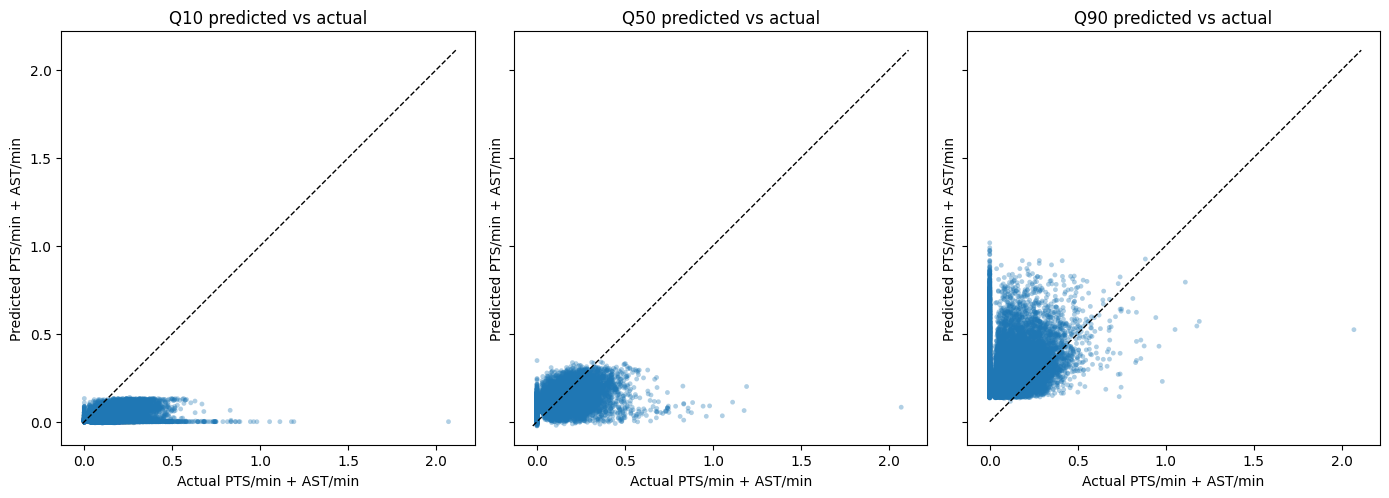

Q10 P(y ≤ pred): 0.1678395327684427
Q50 P(y ≤ pred): 0.4996409593565992
Q90 P(y ≤ pred): 0.9235004069127292
Coverage (10–90 interval): 85.71%


In [22]:
import matplotlib.pyplot as plt

y_true = y_val
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual PTS/min + AST/min")
    ax.set_ylabel("Predicted PTS/min + AST/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")

Generating Global SHAP Summary Plot...


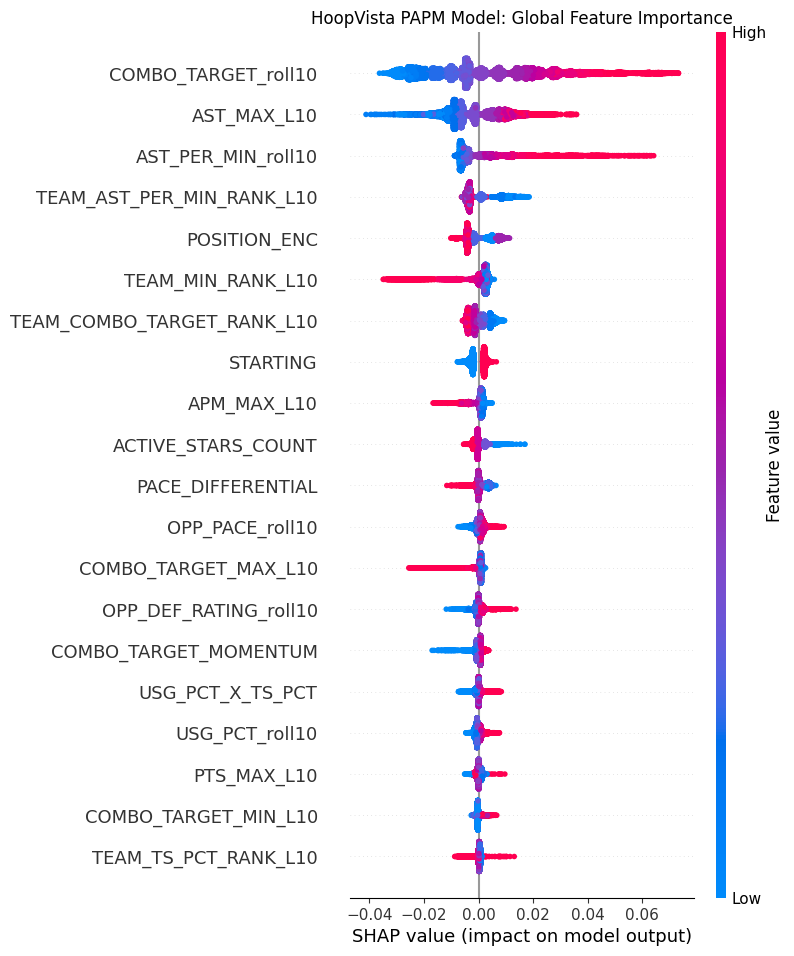

Generating Waterfall Plot for index 1154...


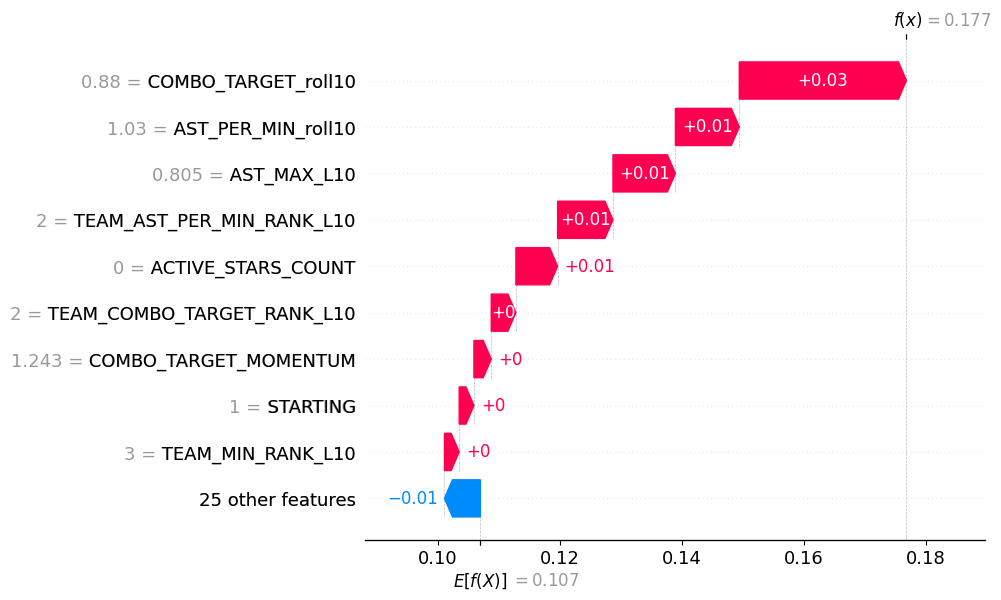

In [23]:
import shap
import matplotlib.pyplot as plt

# 1. Select the specific quantile model
model = quantile_models["q_0.50"]

# 2. Use the unscaled DataFrame to keep features human-readable
# Note: Ensure X_val_ppm index aligns with the data used to train the model
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val) 

# 3. Global Summary Plot
# Use plot_type='dot' for a cleaner look at feature interactions
print("Generating Global SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, show=False)
plt.title("HoopVista PAPM Model: Global Feature Importance")
plt.show()

# 4. Local Waterfall Plot
# check_additivity=False is recommended if your model has custom objectives 
# or complex interaction constraints that SHAP's fast path struggles with.
row_idx = 1154
print(f"Generating Waterfall Plot for index {row_idx}...")
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[row_idx], show=True)

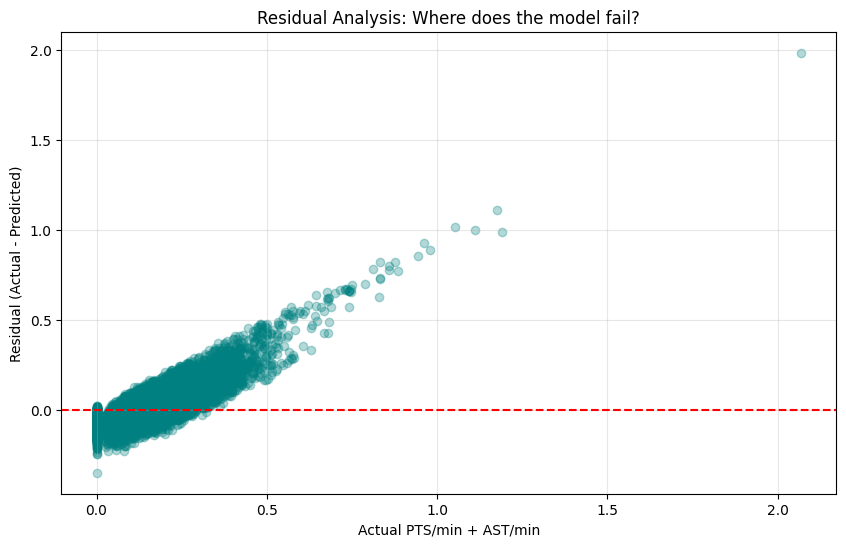

In [24]:
import matplotlib.pyplot as plt

# 1. Calculate Residuals
results["Residual"] = results["Actual"] - results["Median_50"]

# 2. Plot Residuals vs. Actual
plt.figure(figsize=(10, 6))
plt.scatter(results["Actual"], results["Residual"], alpha=0.3, color='teal')

# Add a horizontal line at 0 to show "perfect prediction"
plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel("Actual PTS/min + AST/min")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis: Where does the model fail?")
plt.grid(True, alpha=0.3)
plt.show()

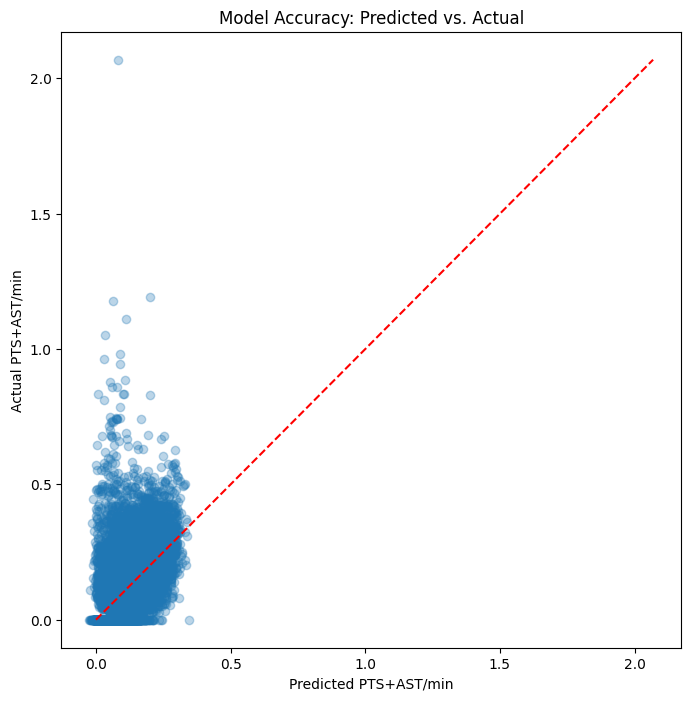

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(results["Median_50"], results["Actual"], alpha=0.3)
plt.plot([results["Actual"].min(), results["Actual"].max()], 
         [results["Actual"].min(), results["Actual"].max()], 'r--')
plt.xlabel("Predicted PTS+AST/min")
plt.ylabel("Actual PTS+AST/min")
plt.title("Model Accuracy: Predicted vs. Actual")
plt.show()

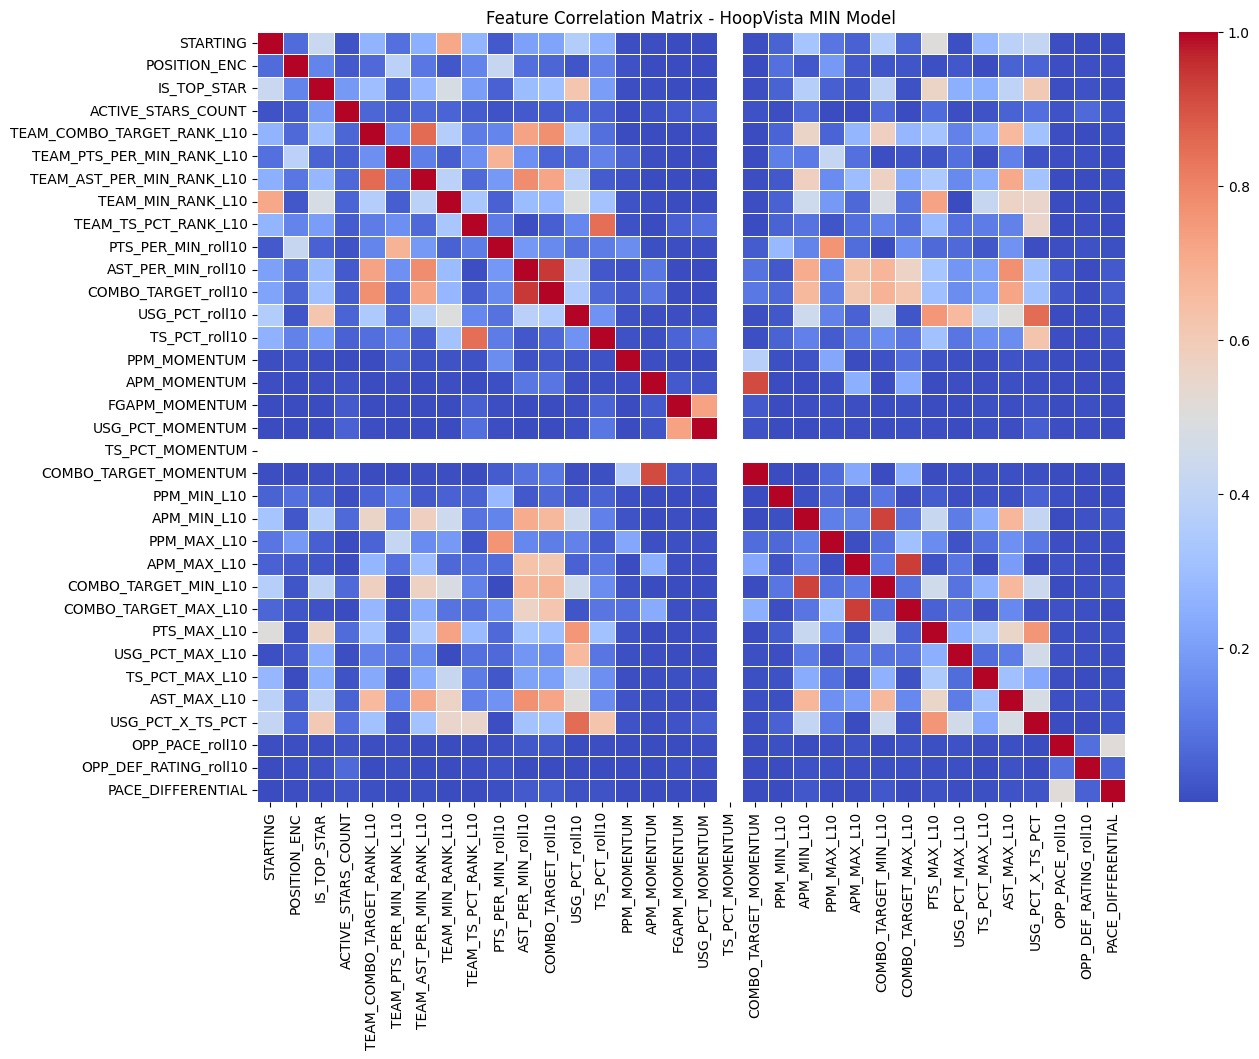

--- High Correlation Report (Threshold > 0.85) ---
COMBO_TARGET_roll10 <-> AST_PER_MIN_roll10: 0.9432
COMBO_TARGET_MAX_L10 <-> APM_MAX_L10: 0.9361
COMBO_TARGET_MIN_L10 <-> APM_MIN_L10: 0.9280
COMBO_TARGET_MOMENTUM <-> APM_MOMENTUM: 0.9133
TEAM_AST_PER_MIN_RANK_L10 <-> TEAM_COMBO_TARGET_RANK_L10: 0.8521
USG_PCT_X_TS_PCT <-> USG_PCT_roll10: 0.8512


['TEAM_AST_PER_MIN_RANK_L10',
 'COMBO_TARGET_roll10',
 'COMBO_TARGET_MOMENTUM',
 'COMBO_TARGET_MIN_L10',
 'COMBO_TARGET_MAX_L10',
 'USG_PCT_X_TS_PCT']

In [26]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.85):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, PAPM_FEATURES)
correlated_features

In [27]:
import joblib
from pathlib import Path


bundle = {
    "quantile_models": quantile_models,
    "feature_names": PAPM_FEATURES,  # or list(X_train_min.columns)
    "scaler": scaler
}
joblib.dump(bundle, "src/models/saved_models/papm_quantile_xgb.joblib")

['src/models/saved_models/papm_quantile_xgb.joblib']

## PPM MODEL + MIN MODEL Analysis

In [15]:
# date = pd.Timestamp.now().normalize()  # midnight today, local tz
# current_date = date.strftime("%Y-%m-%d")

# # target_date = pd.Timestamp("2026-03-26")
# # hist = df[df["GAME_DATE"] < target_date].copy()

# lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
# lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
# lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
# names = lines_dfs['NAME'].unique()
# names

today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')
target_date = pd.Timestamp("2026-04-11")
hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260412_011456.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'PrizePicks') & (lines_dfs['CATEGORY'] == 'player_points_assists')]
names = lines_dfs['NAME'].unique()
names

array(['Jalen Johnson', 'Nickeil Alexander-Walker', 'Tyler Herro',
       'Bam Adebayo', 'C.J. McCollum', 'Dyson Daniels', 'Jaime Jaquez Jr',
       'Onyeka Okongwu', 'Andrew Wiggins', 'Norman Powell',
       'Davion Mitchell', 'Pelle Larsson', 'Paolo Banchero',
       'Desmond Bane', 'Luka Garza', 'Baylor Scheierman', 'Jalen Suggs',
       'Franz Wagner', 'Wendell Carter Jr', 'Brandon Ingram',
       'R.J. Barrett', 'Scottie Barnes', 'Immanuel Quickley',
       'Malachi Smith', 'Jakob Poeltl', 'LaMelo Ball', 'Brandon Miller',
       'Kon Knueppel', 'Miles Bridges', 'Cade Cunningham',
       'Jarace Walker', 'Quenton Jackson', 'Ethan Thompson',
       'Micah Potter', 'Ausar Thompson', 'Tobias Harris',
       'Duncan Robinson', 'Tyrese Maxey', 'Ousmane Dieng', 'VJ Edgecombe',
       'Paul George', 'A.J. Green', 'Cormac Ryan', 'Kelly Oubre Jr',
       'Quentin Grimes', 'Cooper Flagg', 'Collin Sexton', 'Tre Jones',
       'Ryan Nembhard', 'Leonard Miller', 'Rob Dillingham',
       'Max Ch

In [10]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name, current_date)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        ppm_feats = ppm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        ppm_arr = np.asarray(ppm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(ppm_quantile_models["q_0.10"].predict(ppm_arr)[0])
        p50 = float(ppm_quantile_models["q_0.50"].predict(ppm_arr)[0])
        p90 = float(ppm_quantile_models["q_0.90"].predict(ppm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_PPM_Q10": p10,
            "PRED_PPM_Q50": p50,
            "PRED_PPM_Q90": p90,
            "PRED_PTS_Q10": pts10,
            "PRED_PTS_Q50": pts50,
            "PRED_PTS_Q90": pts90,
            "PRED_PTS_RANGE_10_90": pts90 - pts10,
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_PPM_Q10": np.nan,
            "PRED_PPM_Q50": np.nan,
            "PRED_PPM_Q90": np.nan,
            "PRED_PTS_Q10": np.nan,
            "PRED_PTS_Q50": np.nan,
            "PRED_PTS_Q90": np.nan,
            "PRED_PTS_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_PPM_Q10,PRED_PPM_Q50,PRED_PPM_Q90,PRED_PTS_Q10,PRED_PTS_Q50,PRED_PTS_Q90,PRED_PTS_RANGE_10_90
0,Bam Adebayo,7.266884,33.650997,44.387238,0.322626,0.586112,1.035865,2.344489,19.723256,45.979205,43.634716
1,Tyler Herro,11.670135,33.478523,44.817150,0.323220,0.583013,1.067012,3.772024,19.518426,47.820424,44.048400
2,Jaime Jaquez Jr.,14.258892,35.336914,43.086315,0.187986,0.521840,1.004989,2.680470,18.440214,43.301279,40.620809
3,Davion Mitchell,14.405640,33.244370,44.759659,0.154667,0.358826,0.800202,2.228082,11.928931,35.816769,33.588687
4,Kel'el Ware,15.144941,33.324505,40.978050,0.108241,0.427532,0.914231,1.639307,14.247293,37.463394,35.824087
